In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv(r'D:\Project_PA\data\Data_Final_Manggarai_Clean.csv', parse_dates=['tanggal'], index_col='tanggal')
print("Dataset Loaded Successfully!")

df = df.sort_index()

print(df.info())

df = df.dropna()

Dataset Loaded Successfully!
<class 'pandas.DataFrame'>
DatetimeIndex: 38226 entries, 2016-08-22 06:00:00 to 2020-12-31 23:00:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   tinggi_air  38226 non-null  float64
dtypes: float64(1)
memory usage: 597.3 KB
None


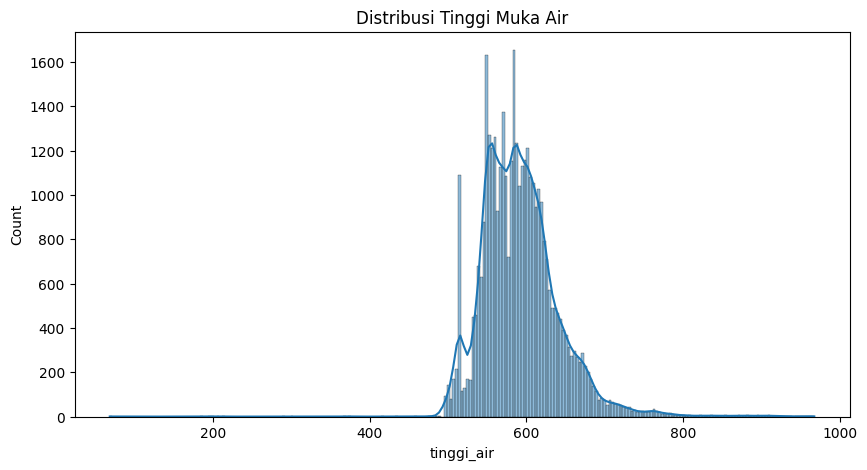

In [58]:
plt.figure(figsize=(10, 5))
sns.histplot(df['tinggi_air'], kde=True)
plt.title('Distribusi Tinggi Muka Air')
plt.show()

In [59]:
# def create_windowed_data(data, window_size=24):
#     X, y = [], []
#     for i in range(len(data) - window_size):
#         X.append(data[i:(i + window_size)])
#         y.append(data[i + window_size])
#     return np.array(X), np.array(y)

# tma_values = df['tinggi_air'].values
# X_raw, y_raw = create_windowed_data(tma_values, window_size=24)
# print(f"Bentuk data X: {X_raw.shape}") 

In [60]:
from sklearn.preprocessing import MinMaxScaler

data = df['tinggi_air'].values.reshape(-1, 1)

scaler_rf = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler_rf.fit_transform(data)

def create_windowed_data(data, window_size=24, offset=6):
    X, y = [], []
    for i in range(len(data) - window_size - offset + 1):
        X.append(data[i:i + window_size, 0])    
        y.append(data[i + window_size + offset - 1, 0]) 
    return np.array(X), np.array(y)

X, y = create_windowed_data(scaled_data)
print(f"Bentuk matriks X untuk RF: {X.shape}") 

Bentuk matriks X untuk RF: (38197, 24)


In [61]:
# Split data (80% Train, 20% Test) tanpa shuffle demi menjaga urutan waktu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"--- Rincian Split Data ---")
print(f"Ukuran X_train (Data Latih) : {X_train.shape}")
print(f"Ukuran X_test  (Data Uji)   : {X_test.shape}")
print(f"Ukuran y_train (Target Latih): {y_train.shape}")
print(f"Ukuran y_test  (Target Uji)  : {y_test.shape}")

--- Rincian Split Data ---
Ukuran X_train (Data Latih) : (30557, 24)
Ukuran X_test  (Data Uji)   : (7640, 24)
Ukuran y_train (Target Latih): (30557,)
Ukuran y_test  (Target Uji)  : (7640,)


In [62]:
rf_model = RandomForestRegressor(
    n_estimators=550, 
    max_depth=24, 
    min_samples_split=20, 
    random_state=42, 
    n_jobs=-1
)

print("Sedang melatih model Random Forest...")
rf_model.fit(X_train, y_train)
print("Training Random Forest Selesai dengan Sukses!")

Sedang melatih model Random Forest...
Training Random Forest Selesai dengan Sukses!


--- HASIL EVALUASI RF ---
RMSE : 26.5742 cm
MAE  : 13.6658 cm
R2   : 0.7735


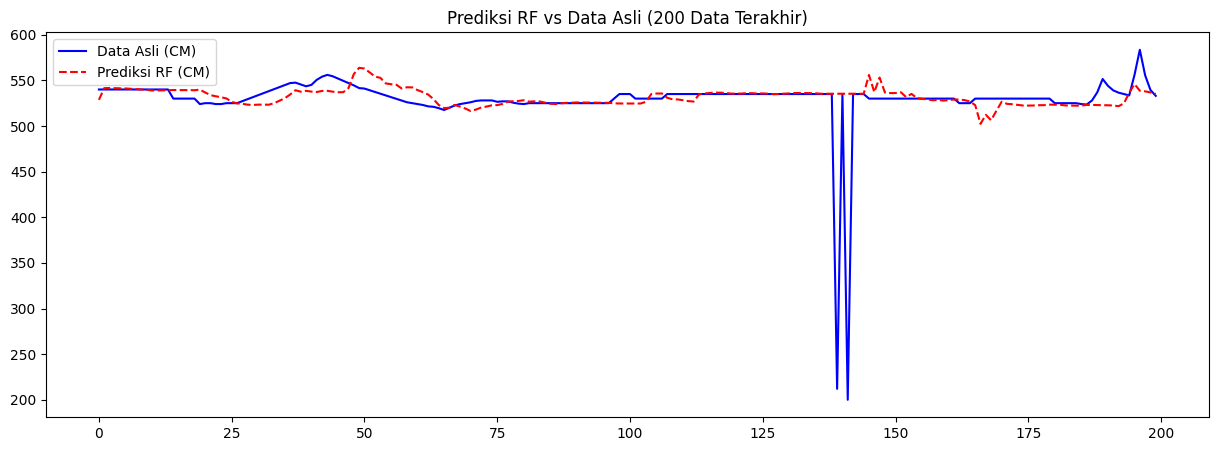

In [63]:
y_pred_scaled = rf_model.predict(X_test)

y_test_cm = scaler_rf.inverse_transform(y_test.reshape(-1, 1))
y_pred_cm = scaler_rf.inverse_transform(y_pred_scaled.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(y_test_cm, y_pred_cm))
mae = mean_absolute_error(y_test_cm, y_pred_cm)
r2 = r2_score(y_test_cm, y_pred_cm)

print(f"--- HASIL EVALUASI RF ---")
print(f"RMSE : {rmse:.4f} cm")
print(f"MAE  : {mae:.4f} cm")
print(f"R2   : {r2:.4f}")

plt.figure(figsize=(15, 5))
plt.plot(y_test_cm[-200:], label="Data Asli (CM)", color='blue')
plt.plot(y_pred_cm[-200:], label="Prediksi RF (CM)", color='red', linestyle='--')
plt.title("Prediksi RF vs Data Asli (200 Data Terakhir)")
plt.legend()
plt.show()

In [64]:
# Folder simpan
MODEL_PATH = r'D:\Project_PA\models'
if not os.path.exists(MODEL_PATH):
    os.makedirs(MODEL_PATH)

# Simpan Model RF
joblib.dump(rf_model, os.path.join(MODEL_PATH, 'model_rf_manggarai.sav'))

# Simpan Scaler RF (Penting biar sinkron sama app.py)
joblib.dump(scaler_rf, os.path.join(MODEL_PATH, 'scaler_rf.sav'))

print(f"Model dan Scaler RF BERHASIL diamankan di: {MODEL_PATH}")

Model dan Scaler RF BERHASIL diamankan di: D:\Project_PA\models
